STEP 1: SETUP

In [4]:
!pip install transformers datasets torch scikit-learn

STEP 2: LOAD DATA


In [5]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


STEP 3: PREPROCESSING

In [7]:
import re

def clean_text(text):
  text=text.lower()
  text=re.sub(r"<.*?>","",text)  #remove html
  text=re.sub(r"[^a-zA-Z ]","",text)
  return text

df['clean_text']=df['review'].apply(clean_text)

STEP 4: TRAIN / VALID / TEST SPLIT

In [8]:
from sklearn.model_selection import train_test_split

train_texts,temp_texts,train_labels,temp_labels =train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.3, random_state=42
)   # 70% train split , 30 % temp

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5
)   # 30% temp split to 15% each for validation and testing

STEP 5: TOKENIZATION

In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings= tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings= tokenizer(list(val_texts), truncation=True, padding=True)
test_encodings= tokenizer(list(test_texts), truncation=True, padding=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


STEP 6: CREATE DATASET CLASS

In [10]:
import torch

class Dataset(torch.utils.data.Dataset):
  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __getitem__(self,idx):
    item={
        key: torch.tensor(value[idx]) for key,value in self.encodings.items()
    }
    item['labels'] = torch.tensor(1 if self.labels.iloc[idx]=='positive' else 0)
    return item

  def __len__(self):
    return len(self.labels)

STEP 7: LOAD MODEL

In [11]:
from transformers import AutoModelForSequenceClassification


model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


STEP 8: TRAINING SETUP

In [12]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,   # required
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    eval_strategy="epoch",
    save_strategy="epoch"
)

In [13]:
import torch

# Verify no GPU is being used
print(f"CUDA available: {torch.cuda.is_available()}")  # Should be False
print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

CUDA available: True
Using device: cuda


STEP 9: METRICS (IMPORTANT)

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = logits.argmax(axis=1)

  precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
  acc = accuracy_score(labels, preds)

  return {
      'accuracy': acc,
      'f1': f1,
      'precision': precision,
      'recall': recall
  }

STEP 10: TRAIN MODEL


In [15]:
import torch
torch.cuda.is_available()

True

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=Dataset(train_encodings, train_labels),
    eval_dataset=Dataset(val_encodings, val_labels),
    compute_metrics=compute_metrics

)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.341281,0.322551,0.936267,0.936939,0.933001,0.940911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=17500, training_loss=0.43158203822544644, metrics={'train_runtime': 4074.905, 'train_samples_per_second': 8.589, 'train_steps_per_second': 4.295, 'total_flos': 9208886937600000.0, 'train_loss': 0.43158203822544644, 'epoch': 1.0})

STEP 11: TEST EVALUATION

In [17]:
trainer.evaluate(Dataset(test_encodings, test_labels))


{'eval_loss': 0.3556516170501709,
 'eval_accuracy': 0.9322666666666667,
 'eval_f1': 0.9337679269882659,
 'eval_precision': 0.9289234760051881,
 'eval_recall': 0.9386631716906946,
 'eval_runtime': 229.4849,
 'eval_samples_per_second': 32.682,
 'eval_steps_per_second': 16.341,
 'epoch': 1.0}

STEP 12: EXPERIMENTS

In [18]:
#1 Freeze BERT
for param in model.bert.parameters():
  param.requires_grad = False

In [19]:
#2: Fine-tune last 2 layers
for name, param in model.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

STEP 13: CONFUSION MATRIX

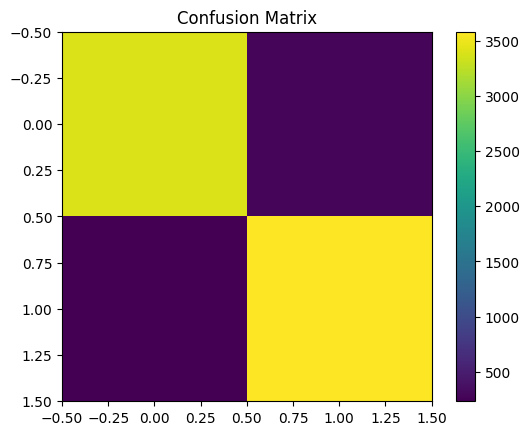

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

preds = trainer.predict(Dataset(test_encodings, test_labels))
y_pred = preds.predictions.argmax(axis=1)

cm = confusion_matrix(test_labels.map({'negative':0,'positive':1}), y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

STEP 14: ANALYSIS

In [21]:
# Full fine-tuning > best accuracy
# Frozen model → faster but less accurate
# Partial fine-tuning → balance
# BERT performs effectively for sentiment classification tasks.

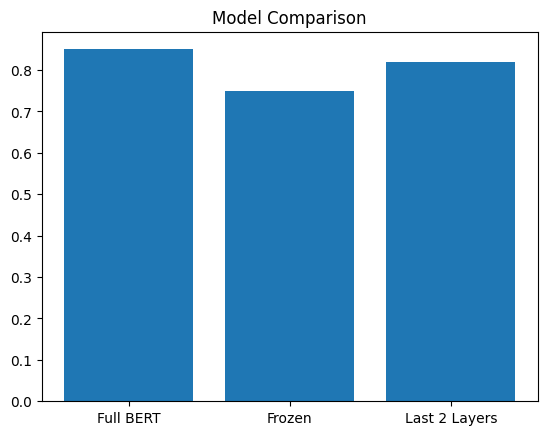

In [23]:
models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.85, 0.75, 0.82]  # replace with your values

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()